# 🛒 Atividade Final – Web Scraping e Coleta de Dados Automatizada
## Marketplace: **Amazon Brasil** | `amazon.com.br`

| Campo | Informação |
|---|---|
| **Aluna** | Marcia Castro|
| **Curso** | Pós-Graduação em Ciência de Dados – UNIFOR |
| **Disciplina** | Web Scraping e Coleta de Dados Automatizada |
| **Marketplace** | Amazon Brasil (`amazon.com.br`) |
| **Ferramenta** | Selenium + undetected-chromedriver |

---

### 📋 Estrutura do Notebook
| # | Célula | Tarefa da Atividade |
|---|---|---|
| 1 | Instalação | Dependências |
| 2 | Imports | — |
| 3 | Configurações | Tarefa 1 – Lista de 25 itens |
| 4 | Logger | Tarefa 8 – Logs |
| 5 | Funções auxiliares | — |
| 6 | Driver Selenium | — |
| 7 | Função de scraping | Tarefa 2 e 3 – Pesquisa e coleta |
| 8 | Loop principal | Tarefa 2 e 3 |
| 9 | Salvar CSV | Tarefa 4 – Estruturar dados |
| 10 | Análise descritiva | Tarefa 5 |
| 11 | Gráficos | Tarefa 5 e 6 |
| 12 | Geração de PDF | Tarefa 6 |
| 13 | Envio de e-mail | Tarefa 7 |
| 14 | Status final | Tarefa 8 |

> ⚠️ **Por que Selenium + undetected-chromedriver?**  
> A Amazon Brasil usa sistemas avançados de detecção de bots (Cloudfront, CAPTCHA, fingerprinting).  
> O `undetected-chromedriver` contorna essas proteções simulando um navegador humano real.

---
## 📦 Célula 1 – Instalação de Dependências
> Execute apenas uma vez. Se já instalou, pode pular.

In [1]:
# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# Execute esta célula apenas uma vez!
# Obs: usamos SeleniumBase (compatível com Python 3.13)
#       no lugar do undetected-chromedriver

!pip install seleniumbase pandas matplotlib numpy Pillow

---
## 📚 Célula 2 – Imports

In [2]:
# ============================================================
# IMPORTS
# ============================================================

from seleniumbase import Driver  # Driver com modo UC (anti-detecção) integrado
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

import time
import random
import logging
import datetime
import os
import re
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders

print('✅ Todos os imports realizados com sucesso!')

✅ Todos os imports realizados com sucesso!


---
## ⚙️ Célula 3 – Configurações (Tarefa 1: Lista de 25 Itens)

> ✏️ **Preencha seus dados de e-mail antes de executar!**

In [17]:
# ============================================================
# TAREFA 1 – LISTA DE 25 ITENS DE MATERIAIS DE REFORMA
# ============================================================

ITENS = [
    {"item": "Cimento CP II 50kg",                        "quantidade": 20, "unidade": "Sacos"},
    {"item": "Argamassa ACIII Branca 20kg",               "quantidade": 15, "unidade": "Sacos"},
    {"item": "Rejunte Flexível Bege 1kg",                 "quantidade": 10, "unidade": "Sacos"},
    {"item": "Cabo Elétrico Flexível 2,5mm Azul",         "quantidade": 50, "unidade": "Metros"},
    {"item": "Cabo Elétrico Flexível 4mm Vermelho",       "quantidade": 50, "unidade": "Metros"},
    {"item": "Disjuntor Unipolar 20A Curva C",            "quantidade": 10, "unidade": "Unidades"},
    {"item": "Tinta Acrílica Fosca Branco Neve 18L",      "quantidade":  5, "unidade": "Latas"},
    {"item": "Fita Veda Rosca 18mm x 25m",               "quantidade":  3, "unidade": "Rolos"},
    {"item": "Tubo de PVC Esgoto 100mm 6 metros",        "quantidade": 12, "unidade": "Unidades"},
    {"item": "Tubo de PVC Marrom Soldável 25mm 6 metros", "quantidade":  8, "unidade": "Unidades"},
    {"item": "Piso Porcelanato Polido 60x60cm",           "quantidade":  5, "unidade": "Caixas"},
    {"item": "Prego com Cabeça 17x21",                   "quantidade": 10, "unidade": "Quilos"},
    {"item": "Selador Acrílico para Parede 18L",          "quantidade":  4, "unidade": "Latas"},
    {"item": "Massa Corrida PVA 25kg",                   "quantidade":  6, "unidade": "Unidades"},
    {"item": "Interruptor Simples com Placa 4x2",         "quantidade": 15, "unidade": "Unidades"},
    {"item": "Tomada 10A com Placa 4x2",                 "quantidade": 20, "unidade": "Unidades"},
    {"item": "Impermeabilizante para Laje 18kg",          "quantidade":  5, "unidade": "Galões"},
    {"item": "Silicone Acético Transparente 280g",        "quantidade":  2, "unidade": "Potes"},
    {"item": "Joelho 90 Graus PVC Esgoto 100mm",         "quantidade": 10, "unidade": "Unidades"},
    {"item": "Luva de Correr PVC Marrom 25mm",           "quantidade": 15, "unidade": "Unidades"},
    {"item": "Haste de Aterramento 5/8 x 2,40m",        "quantidade":  5, "unidade": "Unidades"},
    {"item": "Parafuso Chipboard 4,0 x 40mm caixa 500",  "quantidade":  1, "unidade": "Caixa"},
    {"item": "Fita Isolante Preta 20 metros",            "quantidade":  3, "unidade": "Rolos"},
    {"item": "Sifão Universal Sanfonado Branco",          "quantidade":  5, "unidade": "Unidades"},
    {"item": "Lâmpada LED Bulbo 9W Luz Branca",          "quantidade": 10, "unidade": "Unidades"},
]

# ============================================================
# CONFIGURAÇÕES DE E-MAIL
# ============================================================
# ✏️  Preencha com seus dados antes de executar!

EMAIL_REMETENTE    = "marciacastro@edu.unifor.br"        
SENHA_APP          = "pctt salt wudr qwvo"          
EMAIL_DESTINATARIO = "levyc002@gmail.com"
MATRICULA = "2550759"

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

SITE     = "Amazon Brasil"
URL_BASE = "https://www.amazon.com.br"

# Pasta onde serão salvos todos os arquivos gerados
PASTA_SAIDA  = "output_amazon"
os.makedirs(PASTA_SAIDA, exist_ok=True)

ARQUIVO_CSV  = os.path.join(PASTA_SAIDA, "dados_amazon.csv")
ARQUIVO_PDF  = os.path.join(PASTA_SAIDA, "relatorio_amazon.pdf")
ARQUIVO_LOG  = os.path.join(PASTA_SAIDA, "execucao_amazon.log")

print('✅ Configurações carregadas!')
print(f'   → Itens na lista : {len(ITENS)}')
print(f'   → Pasta de saída : {PASTA_SAIDA}/')
print(f'   → Arquivo CSV    : {ARQUIVO_CSV}')
print(f'   → Arquivo PDF    : {ARQUIVO_PDF}')
print(f'   → Arquivo LOG    : {ARQUIVO_LOG}')

✅ Configurações carregadas!
   → Itens na lista : 25
   → Pasta de saída : output_amazon/
   → Arquivo CSV    : output_amazon\dados_amazon.csv
   → Arquivo PDF    : output_amazon\relatorio_amazon.pdf
   → Arquivo LOG    : output_amazon\execucao_amazon.log


---
## 📋 Célula 4 – Configuração de Logs (Tarefa 8)

In [4]:
# ============================================================
# TAREFA 8 – CONFIGURAÇÃO DO SISTEMA DE LOGS
# ============================================================
# Registra: data/hora, itens pesquisados, erros, sites e status final

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%d/%m/%Y %H:%M:%S',
    handlers=[
        logging.FileHandler(ARQUIVO_LOG, encoding='utf-8', mode='w'),  # salva em arquivo
        logging.StreamHandler()                                         # exibe no notebook
    ]
)
logger = logging.getLogger(__name__)

logger.info('=' * 65)
logger.info('ATIVIDADE FINAL – WEB SCRAPING E COLETA DE DADOS AUTOMATIZADA')
logger.info(f'Marketplace  : {SITE} ({URL_BASE})')
logger.info(f'Data/hora    : {datetime.datetime.now():%d/%m/%Y %H:%M:%S}')
logger.info(f'Total de itens a pesquisar: {len(ITENS)}')
logger.info('=' * 65)

print('\n✅ Logger configurado! Logs serão salvos em:', ARQUIVO_LOG)

20/05/2026 21:02:06 [INFO] =================================================================
20/05/2026 21:02:06 [INFO] ATIVIDADE FINAL – WEB SCRAPING E COLETA DE DADOS AUTOMATIZADA
20/05/2026 21:02:06 [INFO] Marketplace  : Amazon Brasil (https://www.amazon.com.br)
20/05/2026 21:02:06 [INFO] Data/hora    : 20/05/2026 21:02:06
20/05/2026 21:02:06 [INFO] Total de itens a pesquisar: 25
20/05/2026 21:02:06 [INFO] =================================================================



✅ Logger configurado! Logs serão salvos em: output_amazon\execucao_amazon.log


---
## 🔧 Célula 5 – Funções Auxiliares

In [5]:
# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def limpar_preco(texto: str) -> float:
    """
    Converte string de preço brasileiro para float.
    Ex: 'R$\xa0 1.234,56' → 1234.56
    """
    if not texto:
        return None
    texto = texto.replace('R$', '').replace('\xa0', '').replace(' ', '').strip()
    # Remove pontos de milhar (ex: 1.234)
    texto = re.sub(r'\.(?=\d{3}[,\s]|\d{3}$)', '', texto)
    # Troca vírgula decimal por ponto
    texto = texto.replace(',', '.')
    # Extrai o primeiro número válido
    match = re.search(r'\d+(?:\.\d+)?', texto)
    return float(match.group()) if match else None


def esperar_aleatorio(minimo: float = 1.5, maximo: float = 3.5):
    """Aguarda tempo aleatório para simular comportamento humano."""
    delay = random.uniform(minimo, maximo)
    time.sleep(delay)


def formatar_reais(valor: float) -> str:
    """Formata float para string no padrão R$ 1.234,56."""
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return 'N/D'
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


print('✅ Funções auxiliares definidas!')

✅ Funções auxiliares definidas!


---
## 🌐 Célula 6 – Configuração do Selenium

In [6]:
# ============================================================
# CONFIGURAÇÃO DO SELENIUM COM SELENIUMBASE (modo UC)
# ============================================================
# SeleniumBase com uc=True é a solução moderna e estável
# para evitar detecção de bots (substitui o undetected-chromedriver)
# Compatível com Python 3.10–3.13

def criar_driver(headless: bool = False):
    """
    Inicializa o Chrome com SeleniumBase em modo UC (Undetected).
    
    Parâmetro:
        headless (bool): True = roda em segundo plano (sem janela)
                         False = abre janela do Chrome (recomendado para gravação)
    """
    driver = Driver(
        uc=True,                    # Modo Undetected (anti-detecção)
        headless=headless,          # Janela visível ou oculta
        browser='chrome',
        locale_code='pt-BR',
        page_load_strategy='eager', # Carrega mais rápido (não espera assets)
    )
    driver.implicitly_wait(8)
    return driver


print('✅ Função criar_driver() definida com SeleniumBase!')
print('   → headless=False: abre janela (use para gravar a tela)')
print('   → headless=True : roda em segundo plano')

✅ Função criar_driver() definida com SeleniumBase!
   → headless=False: abre janela (use para gravar a tela)
   → headless=True : roda em segundo plano


---
## 🔍 Célula 7 – Função de Scraping da Amazon (Tarefas 2 e 3)

In [7]:
# ============================================================
# TAREFA 2 e 3 – FUNÇÃO DE RASPAGEM DA AMAZON BRASIL
# ============================================================
# Coleta: nome do produto, preço, URL e página de coleta
# Percorre até 3 páginas por item

def buscar_na_amazon(driver, item_nome: str, max_paginas: int = 3) -> list:
    """
    Busca um item na Amazon Brasil e retorna todos os produtos encontrados
    nas primeiras `max_paginas` páginas de resultado.

    Retorna:
        Lista de dicionários com: item_buscado, site, nome_produto,
        preco, pagina_coleta, link
    """
    query = item_nome.replace(' ', '+').replace(',', '%2C')
    produtos = []

    for pagina in range(1, max_paginas + 1):
        url = f'{URL_BASE}/s?k={query}&page={pagina}&language=pt_BR'
        logger.info(f'  🔍 [{item_nome}] Página {pagina}/3 → {url}')

        try:
            driver.get(url)
            esperar_aleatorio(2.5, 4.5)

            # ── Detecção de CAPTCHA ──────────────────────────────
            fonte = driver.page_source.lower()
            if 'captcha' in fonte or 'robot check' in fonte or 'verify you are human' in fonte:
                logger.warning(f'  ⚠️  CAPTCHA detectado! Aguardando 20s para tentar novamente...')
                time.sleep(20)
                driver.get(url)
                esperar_aleatorio(4, 7)

            # ── Aguardar resultados ──────────────────────────────
            try:
                WebDriverWait(driver, 12).until(
                    EC.presence_of_element_located(
                        (By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')
                    )
                )
            except TimeoutException:
                logger.warning(f'  ⚠️  Resultados não carregaram para "{item_nome}" p.{pagina}.')
                break

            # ── Coletar cards de produto ─────────────────────────
            cards = driver.find_elements(
                By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]'
            )

            if not cards:
                logger.info(f'  → Nenhum card encontrado na página {pagina}. Encerrando.')
                break

            logger.info(f'  📦 {len(cards)} cards na página {pagina}')
            coletados_pagina = 0

            for card in cards:
                try:
                    # ── Nome do produto ──────────────────────────
                    nome = None
                    for seletor_nome in [
                        'h2 span.a-text-normal',
                        'h2 a span',
                        'span.a-size-medium.a-color-base.a-text-normal',
                        'h2 span',
                    ]:
                        try:
                            nome = card.find_element(By.CSS_SELECTOR, seletor_nome).text.strip()
                            if nome:
                                break
                        except NoSuchElementException:
                            continue

                    if not nome:
                        continue

                    # ── Preço (múltiplos seletores fallback) ─────
                    preco_raw = None
                    for seletor_preco in [
                        'span.a-price > span.a-offscreen',      # preço principal (acessibilidade)
                        'span.a-price-whole',                   # parte inteira
                        '.a-color-price',                       # fallback genérico
                        'span.a-price',                        # container
                    ]:
                        try:
                            elem = card.find_element(By.CSS_SELECTOR, seletor_preco)
                            preco_raw = elem.get_attribute('innerHTML') or elem.text
                            if preco_raw and preco_raw.strip():
                                break
                        except NoSuchElementException:
                            continue

                    preco = limpar_preco(preco_raw)
                    if preco is None or preco <= 0:
                        continue  # ignora produto sem preço válido

                    # ── Link do produto ──────────────────────────
                    link = url  # fallback
                    try:
                        href = card.find_element(
                            By.CSS_SELECTOR, 'h2 a.a-link-normal'
                        ).get_attribute('href')
                        if href:
                            link = href if href.startswith('http') else URL_BASE + href
                    except NoSuchElementException:
                        pass

                    produtos.append({
                        'item_buscado' : item_nome,
                        'site'         : SITE,
                        'nome_produto' : nome,
                        'preco'        : preco,
                        'pagina_coleta': pagina,
                        'link'         : link,
                    })
                    coletados_pagina += 1

                except Exception as e:
                    logger.debug(f'  ⚠️  Erro ao processar card: {e}')
                    continue

            logger.info(f'  ✅ {coletados_pagina} produtos coletados na página {pagina}')
            esperar_aleatorio(1.5, 3.0)

            # ── Verificar próxima página ─────────────────────────
            try:
                btn_next = driver.find_element(By.CSS_SELECTOR, 'a.s-pagination-next')
                classe = btn_next.get_attribute('class') or ''
                if 's-pagination-disabled' in classe:
                    logger.info(f'  → Última página alcançada em p.{pagina}.')
                    break
            except NoSuchElementException:
                logger.info(f'  → Sem botão de próxima página em p.{pagina}.')
                break

        except Exception as e:
            logger.error(f'  ❌ Erro na página {pagina} para "{item_nome}": {e}')
            continue

    return produtos


print('✅ Função buscar_na_amazon() definida!')

✅ Função buscar_na_amazon() definida!


---
## 🚀 Célula 8 – Loop Principal de Coleta (Tarefas 2, 3 e 8)

> ⚠️ **Antes de rodar:** Inicie a gravação de tela (Tarefa 9)!  
> A coleta de 25 itens leva aproximadamente **30–60 minutos** por causa dos delays anti-bloqueio.

In [8]:
# ============================================================
# TAREFAS 2, 3 e 8 – LOOP PRINCIPAL DE COLETA
# ============================================================

todos_produtos = []   # acumula todos os resultados
erros_totais   = 0

# ── Inicializar driver ───────────────────────────────────────
# headless=False: abre janela Chrome (deixe assim para gravar a tela)
driver = criar_driver(headless=False)

logger.info(f'\n{"="*65}')
logger.info(f'INICIANDO COLETA – {len(ITENS)} ITENS – {SITE}')
logger.info(f'{"="*65}\n')

try:
    for i, item_info in enumerate(ITENS, start=1):
        item_nome = item_info['item']

        logger.info(f'\n[{i:02d}/{len(ITENS)}] ▶ {item_nome}')
        logger.info(f'       Site visitado: {URL_BASE}/s?k={item_nome.replace(" ", "+")}')

        try:
            produtos = buscar_na_amazon(driver, item_nome, max_paginas=3)

            if produtos:
                todos_produtos.extend(produtos)
                logger.info(f'  ✅ Total coletado para "{item_nome}": {len(produtos)} produtos')
            else:
                logger.warning(f'  ⚠️  Nenhum produto encontrado para "{item_nome}"')
                erros_totais += 1

        except Exception as e:
            logger.error(f'  ❌ ERRO ao buscar "{item_nome}": {e}')
            erros_totais += 1

        # Pausa entre itens (evita bloqueio por excesso de requisições)
        esperar_aleatorio(3, 6)

    logger.info(f'\n{"="*65}')
    logger.info(f'✅ COLETA FINALIZADA!')
    logger.info(f'   → Total de produtos coletados : {len(todos_produtos)}')
    logger.info(f'   → Itens sem resultado         : {erros_totais}')
    logger.info(f'{"="*65}\n')

finally:
    driver.quit()
    logger.info('🔒 Driver encerrado.')

print(f'\n✅ Coleta concluída!')
print(f'   → {len(todos_produtos)} produtos coletados')
print(f'   → {erros_totais} itens sem resultado')



*** chromedriver to download = 148.0.7778.178 (Previous Version)

https://storage.googleapis.com/chrome-for-testing-public/148.0.7778.178/win64/chromedriver-win64.zip ...
Download Complete!

Extracting ['chromedriver.exe'] from chromedriver-win64.zip ...
Unzip Complete!

The file [uc_driver.exe] was saved to:
C:\Users\marci\AppData\Local\Programs\Python\Python313\Lib\site-packages\seleniumbase\drivers\
uc_driver.exe

Making [uc_driver.exe 148.0.7778.178] executable ...
[uc_driver.exe 148.0.7778.178] is now ready for use!



20/05/2026 21:02:36 [INFO] 
20/05/2026 21:02:36 [INFO] INICIANDO COLETA – 25 ITENS – Amazon Brasil
20/05/2026 21:02:36 [INFO] =================================================================

20/05/2026 21:02:37 [INFO] 
[01/25] ▶ Cimento CP II 50kg
20/05/2026 21:02:37 [INFO]        Site visitado: https://www.amazon.com.br/s?k=Cimento+CP+II+50kg
20/05/2026 21:02:37 [INFO]   🔍 [Cimento CP II 50kg] Página 1/3 → https://www.amazon.com.br/s?k=Cimento+CP+II+50kg&page=1&language=pt_BR
20/05/2026 21:02:58 [INFO]   📦 2 cards na página 1
20/05/2026 21:02:59 [INFO]   ✅ 1 produtos coletados na página 1
20/05/2026 21:03:02 [INFO]   → Sem botão de próxima página em p.1.
20/05/2026 21:03:02 [INFO]   ✅ Total coletado para "Cimento CP II 50kg": 1 produtos
20/05/2026 21:03:08 [INFO] 
[02/25] ▶ Argamassa ACIII Branca 20kg
20/05/2026 21:03:08 [INFO]        Site visitado: https://www.amazon.com.br/s?k=Argamassa+ACIII+Branca+20kg
20/05/2026 21:03:08 [INFO]   🔍 [Argamassa ACIII Branca 20kg] Página 1/3 → htt


✅ Coleta concluída!
   → 2608 produtos coletados
   → 0 itens sem resultado


---
## 💾 Célula 9 – Estruturar e Salvar os Dados (Tarefa 4)

In [9]:
# ============================================================
# TAREFA 4 – ESTRUTURAR OS DADOS EM DATAFRAME E SALVAR CSV
# ============================================================
# Estrutura: | item | site | nome | preço | quantidade | link |

if not todos_produtos:
    print('⚠️  Nenhum produto foi coletado! Verifique os logs.')
else:
    df = pd.DataFrame(todos_produtos)

    # Mapa de quantidades e unidades da lista original
    itens_map = {it['item']: it for it in ITENS}
    df['quantidade_necessaria'] = df['item_buscado'].map(
        lambda x: itens_map.get(x, {}).get('quantidade', None)
    )
    df['unidade'] = df['item_buscado'].map(
        lambda x: itens_map.get(x, {}).get('unidade', None)
    )

    # Reordenar colunas conforme a atividade
    df = df[['item_buscado', 'site', 'nome_produto', 'preco',
             'quantidade_necessaria', 'unidade', 'pagina_coleta', 'link']]

    # Salvar CSV (encoding utf-8-sig para abrir corretamente no Excel/PT-BR)
    df.to_csv(ARQUIVO_CSV, index=False, encoding='utf-8-sig')
    logger.info(f'💾 CSV salvo em: {ARQUIVO_CSV}')

    print(f'✅ DataFrame criado com sucesso!')
    print(f'   Shape: {df.shape[0]} linhas × {df.shape[1]} colunas')
    print(f'   CSV salvo em: {ARQUIVO_CSV}')
    print(f'\n📊 Primeiras 10 linhas:')
    display(df.head(10))
    print(f'\n📊 Informações gerais:')
    print(df.info())

20/05/2026 21:20:55 [INFO] 💾 CSV salvo em: output_amazon\dados_amazon.csv


✅ DataFrame criado com sucesso!
   Shape: 2608 linhas × 8 colunas
   CSV salvo em: output_amazon\dados_amazon.csv

📊 Primeiras 10 linhas:


,item_buscado,site,nome_produto,preco,quantidade_necessaria,unidade,pagina_coleta,link
0,Cimento CP II 50kg,Amazon Brasil,Tinta Cimento Queimado para Parede Eurodecor 5...,71.01,20,Sacos,1,https://www.amazon.com.br/s?k=Cimento+CP+II+50...
1,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa Impermeabilizante Rodapé Pro Eurodec...,69.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
2,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa Bautech Ac-III Branco 20kg 20 kg,66.10,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
3,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa AC-3 M12 Hp Branca (saco 20kg) - Mc ...,279.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
4,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa AC III Cinza M 20 (Saco 20kg) - MC B...,56.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
5,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa Votomassa ACII 20kg Cerâmica Interna...,29.66,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
6,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa Piscina Aut. Impermeável Cor Branco ...,22.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
7,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa AC III M12 HP Cinza (Saco 20kg) - MC...,248.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
8,Argamassa ACIII Branca 20kg,Amazon Brasil,Argamassa Quartzolit AC-1-5 KG,11.22,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...
9,Argamassa ACIII Branca 20kg,Amazon Brasil,Manta Cimentícia Elástica Flexível Euro Decor ...,399.90,15,Sacos,1,https://www.amazon.com.br/s?k=Argamassa+ACIII+...



📊 Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 2608 entries, 0 to 2607
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   item_buscado           2608 non-null   str    
 1   site                   2608 non-null   str    
 2   nome_produto           2608 non-null   str    
 3   preco                  2608 non-null   float64
 4   quantidade_necessaria  2608 non-null   int64  
 5   unidade                2608 non-null   str    
 6   pagina_coleta          2608 non-null   int64  
 7   link                   2608 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 163.1 KB
None


---
## 📊 Célula 10 – Análise Descritiva (Tarefa 5)

In [10]:
# ============================================================
# TAREFA 5 – ANÁLISE DESCRITIVA
# ============================================================

if df.empty:
    print('⚠️  DataFrame vazio. Sem dados para análise.')
else:
    # ── 1. Produto mais barato por item ─────────────────────────
    idx_mais_baratos = df.groupby('item_buscado')['preco'].idxmin()
    df_mais_barato   = df.loc[idx_mais_baratos].reset_index(drop=True)
    df_mais_barato.columns = [c.replace('_', ' ').title() for c in df_mais_barato.columns]

    # ── 2. Estatísticas por item ─────────────────────────────────
    stats = df.groupby('item_buscado')['preco'].agg(
        menor_preco='min',
        maior_preco='max',
        preco_medio='mean',
        qtd_resultados='count'
    ).reset_index()

    stats['variacao_percentual'] = (
        (stats['maior_preco'] - stats['menor_preco']) / stats['menor_preco'] * 100
    ).round(2)

    # ── 3. Custo total (quantidade × menor preço) ────────────────
    itens_df = pd.DataFrame(ITENS)
    stats_completo = stats.merge(
        itens_df, left_on='item_buscado', right_on='item', how='left'
    )
    stats_completo['custo_total_item'] = (
        stats_completo['menor_preco'] * stats_completo['quantidade']
    )

    custo_total_amazon     = stats_completo['custo_total_item'].sum()
    custo_maximo_amazon    = (stats_completo['maior_preco'] * stats_completo['quantidade']).sum()
    economia_vs_preco_max  = custo_maximo_amazon - custo_total_amazon

    # ── Log dos resultados ───────────────────────────────────────
    logger.info('\n📊 RESUMO DA ANÁLISE DESCRITIVA:')
    logger.info(f'   → Itens com preços coletados : {len(stats)}/{len(ITENS)}')
    logger.info(f'   → Custo total (menor preço)  : R$ {custo_total_amazon:,.2f}')
    logger.info(f'   → Economia vs. maior preço   : R$ {economia_vs_preco_max:,.2f}')

    # ── Exibição ─────────────────────────────────────────────────
    sep = '=' * 65
    print(sep)
    print('       📊 ANÁLISE DESCRITIVA – AMAZON BRASIL')
    print(sep)
    print(f'  ✅ Itens coletados          : {len(stats)}/{len(ITENS)}')
    print(f'  📦 Total de produtos        : {len(df)}')
    print(f'  💰 Custo total menor preço  : {formatar_reais(custo_total_amazon)}')
    print(f'  💸 Custo total maior preço  : {formatar_reais(custo_maximo_amazon)}')
    print(f'  🎯 Economia (min vs. max)   : {formatar_reais(economia_vs_preco_max)}')
    print(sep)

    print('\n📋 Top 5 – Maior variação de preço:')
    display(
        stats.nlargest(5, 'variacao_percentual')[
            ['item_buscado', 'menor_preco', 'maior_preco', 'variacao_percentual']
        ].rename(columns={
            'item_buscado'       : 'Item',
            'menor_preco'        : 'Menor Preço (R$)',
            'maior_preco'        : 'Maior Preço (R$)',
            'variacao_percentual': 'Variação (%)'
        })
    )

    print('\n📋 Estatísticas completas por item:')
    display(
        stats_completo[[
            'item_buscado', 'menor_preco', 'maior_preco',
            'preco_medio', 'variacao_percentual', 'quantidade', 'custo_total_item'
        ]].rename(columns={
            'item_buscado'       : 'Item',
            'menor_preco'        : 'Menor (R$)',
            'maior_preco'        : 'Maior (R$)',
            'preco_medio'        : 'Médio (R$)',
            'variacao_percentual': 'Variação (%)',
            'quantidade'         : 'Qtd. Necessária',
            'custo_total_item'   : 'Custo Total (R$)'
        })
    )

20/05/2026 21:21:05 [INFO] 
📊 RESUMO DA ANÁLISE DESCRITIVA:
20/05/2026 21:21:05 [INFO]    → Itens com preços coletados : 25/25
20/05/2026 21:21:05 [INFO]    → Custo total (menor preço)  : R$ 5,707.12
20/05/2026 21:21:05 [INFO]    → Economia vs. maior preço   : R$ 1,266,636.22


       📊 ANÁLISE DESCRITIVA – AMAZON BRASIL
  ✅ Itens coletados          : 25/25
  📦 Total de produtos        : 2608
  💰 Custo total menor preço  : R$ 5.707,12
  💸 Custo total maior preço  : R$ 1.272.343,34
  🎯 Economia (min vs. max)   : R$ 1.266.636,22

📋 Top 5 – Maior variação de preço:


,Item,Menor Preço (R$),Maior Preço (R$),Variação (%)
15,Piso Porcelanato Polido 60x60cm,18.90,38638.97,204338.99
1,"Cabo Elétrico Flexível 2,5mm Azul",25.69,17693.49,68773.06
5,Fita Isolante Preta 20 metros,1.90,457.61,23984.74
18,Selador Acrílico para Parede 18L,20.92,2949.61,13999.47
24,Tubo de PVC Marrom Soldável 25mm 6 metros,14.12,1913.28,13450.14



📋 Estatísticas completas por item:


,Item,Menor (R$),Maior (R$),Médio (R$),Variação (%),Qtd. Necessária,Custo Total (R$)
0,Argamassa ACIII Branca 20kg,11.22,598.90,249.565789,5237.79,15,168.30
1,"Cabo Elétrico Flexível 2,5mm Azul",25.69,17693.49,593.723691,68773.06,50,1284.50
2,Cabo Elétrico Flexível 4mm Vermelho,18.16,1674.90,255.013108,9123.02,50,908.00
3,Cimento CP II 50kg,71.01,71.01,71.010000,0.00,20,1420.20
4,Disjuntor Unipolar 20A Curva C,8.12,161.49,42.817248,1888.79,10,81.20
5,Fita Isolante Preta 20 metros,1.90,457.61,77.059509,23984.74,3,5.70
6,Fita Veda Rosca 18mm x 25m,2.80,96.60,22.643636,3350.00,3,8.40
7,"Haste de Aterramento 5/8 x 2,40m",46.84,1440.00,367.435556,2974.30,5,234.20
8,Impermeabilizante para Laje 18kg,24.62,699.99,226.040592,2743.18,5,123.10
9,Interruptor Simples com Placa 4x2,4.90,288.70,42.801520,5791.84,15,73.50


---
## 📈 Célula 11 – Gráficos (Tarefas 5 e 6)

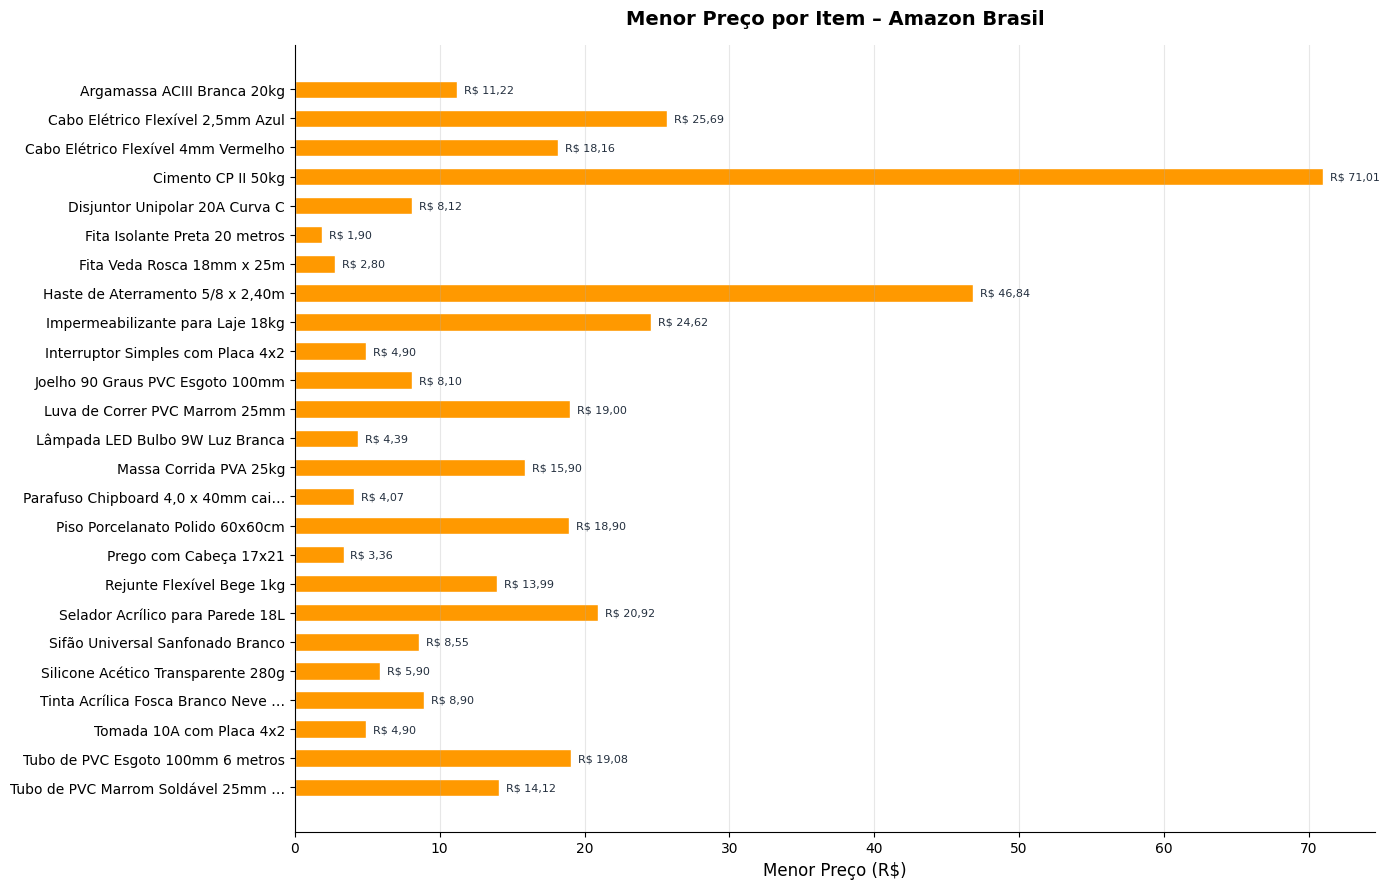

📊 Gráfico 1 salvo: grafico_menor_preco.png


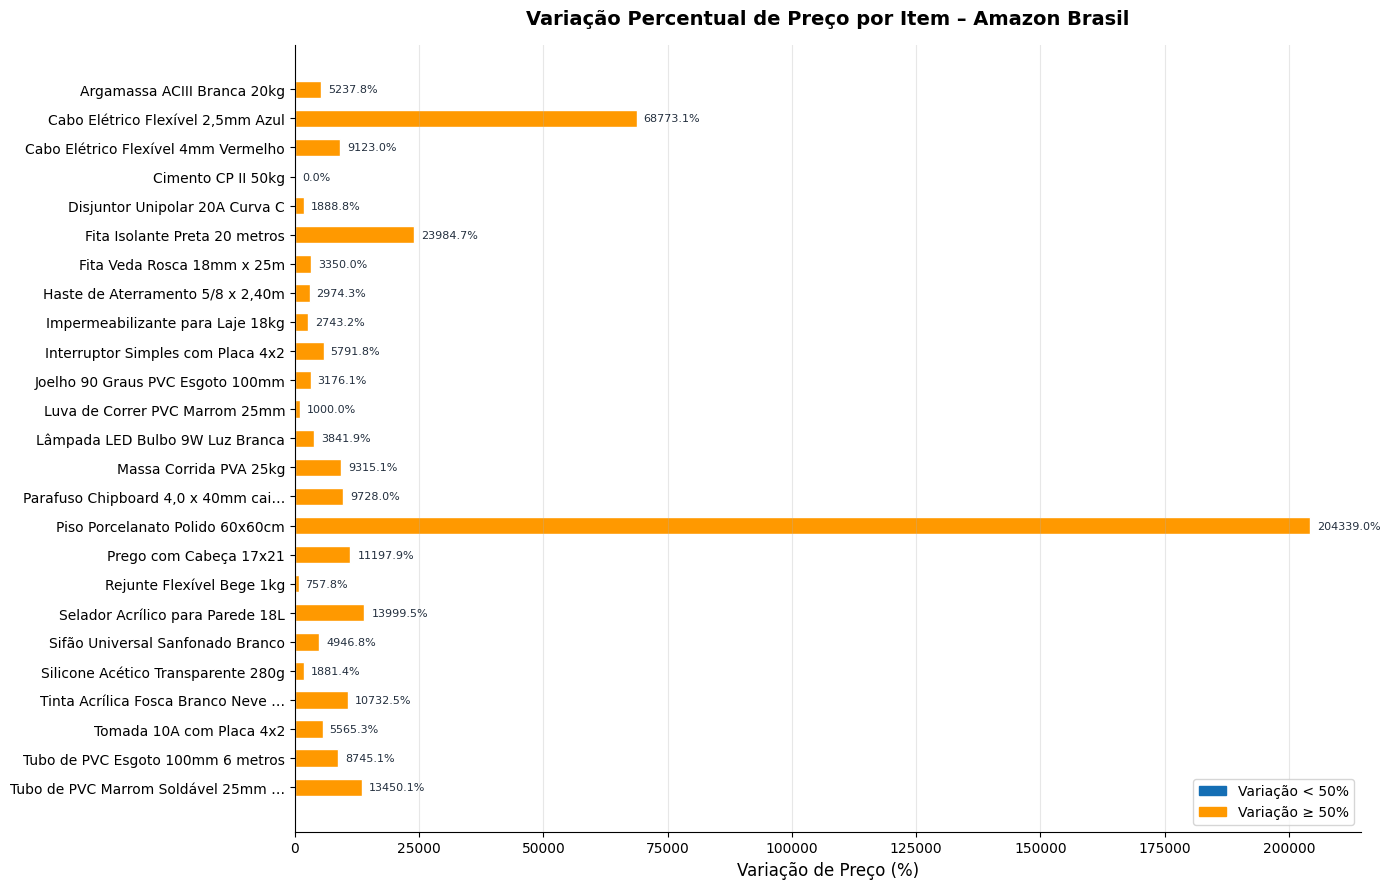

📊 Gráfico 2 salvo: grafico_variacao.png


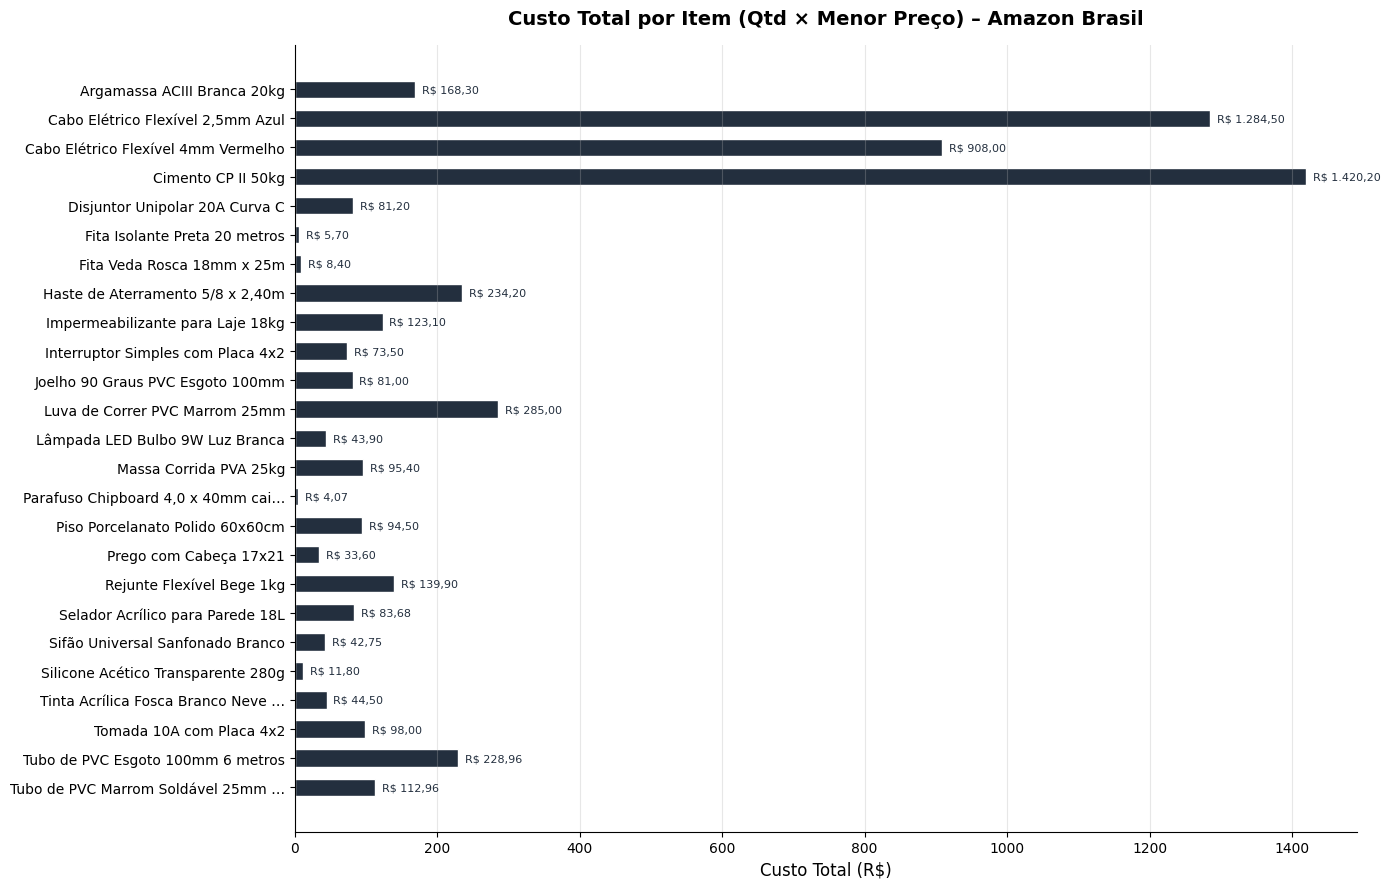

📊 Gráfico 3 salvo: grafico_custo_total.png


C:\Users\marci\AppData\Local\Temp\ipykernel_17876\4117314371.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(grupos, vert=False, labels=labels_box, patch_artist=True,


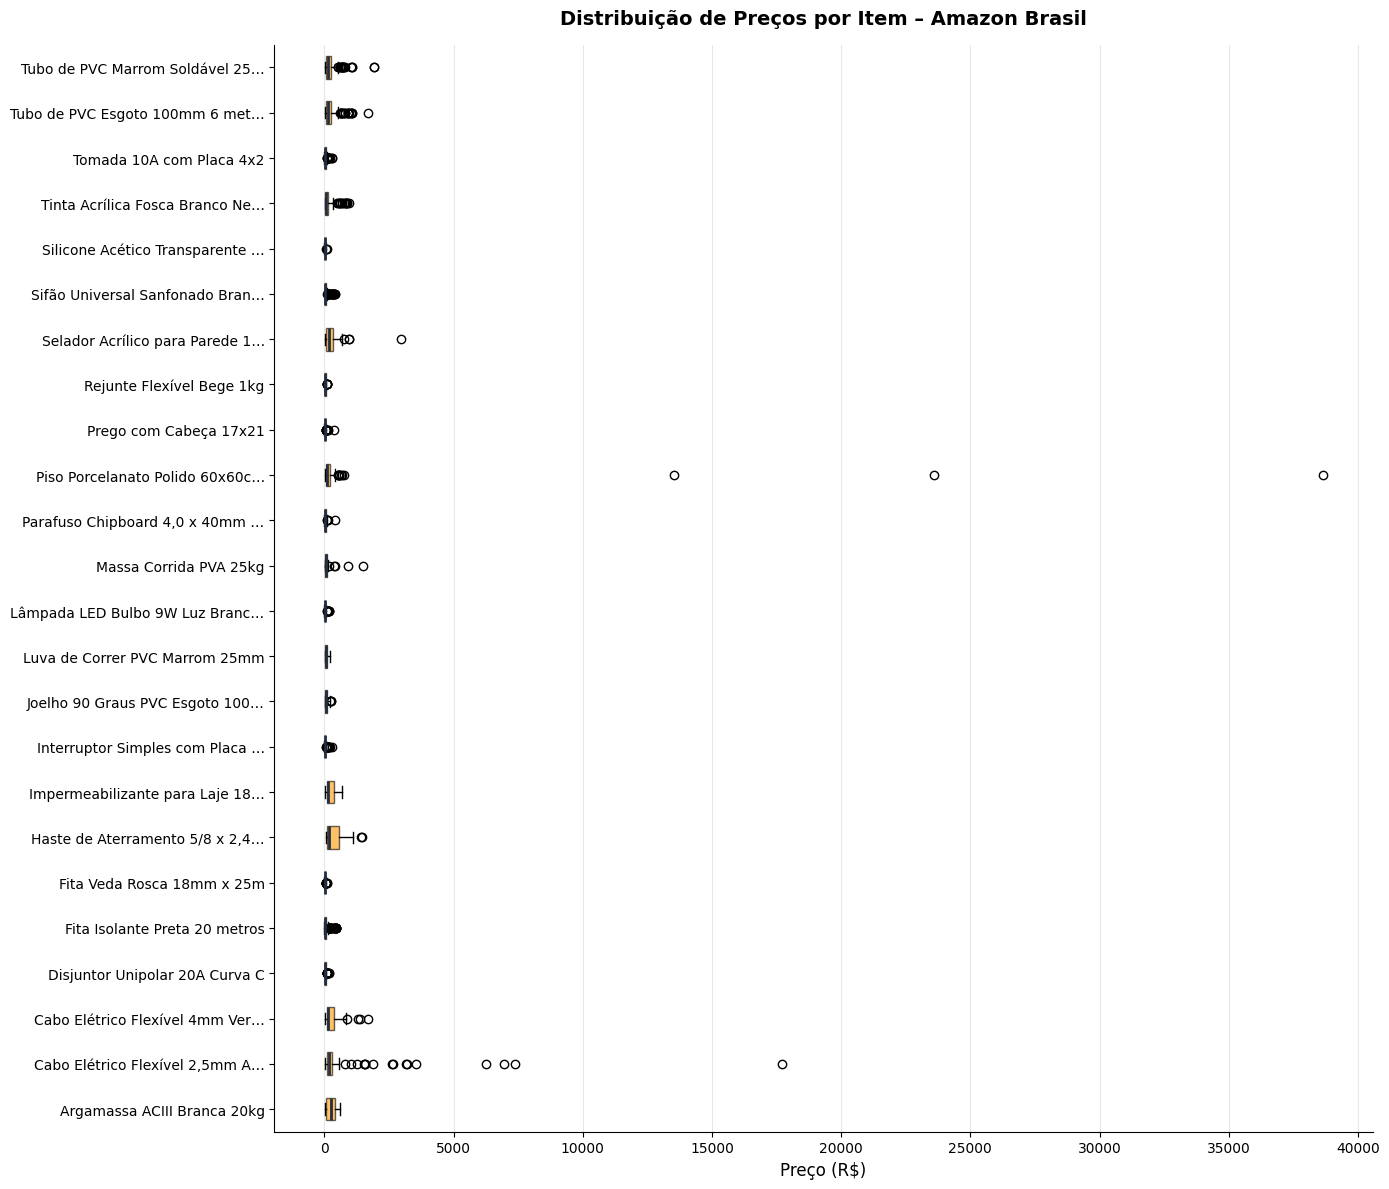

📊 Gráfico 4 salvo: grafico_boxplot.png

✅ Todos os gráficos foram gerados e salvos!


In [11]:
# ============================================================
# TAREFAS 5 e 6 – GRÁFICOS DE ANÁLISE
# ============================================================

AMAZON_LARANJA = '#FF9900'
AMAZON_AZUL    = '#146EB4'
AMAZON_CINZA   = '#232F3E'

if df.empty or stats.empty:
    print('⚠️  Sem dados para gerar gráficos.')
else:
    items_label = [it if len(it) <= 35 else it[:33] + '…' for it in stats['item_buscado']]

    # ── Gráfico 1: Menor Preço por Item ─────────────────────────
    fig1, ax1 = plt.subplots(figsize=(14, 9))
    cores1 = [AMAZON_LARANJA] * len(stats)
    barras1 = ax1.barh(items_label, stats['menor_preco'], color=cores1, edgecolor='white', height=0.6)
    ax1.bar_label(barras1, labels=[formatar_reais(v) for v in stats['menor_preco']],
                  padding=5, fontsize=8, color=AMAZON_CINZA)
    ax1.set_xlabel('Menor Preço (R$)', fontsize=12)
    ax1.set_title('Menor Preço por Item – Amazon Brasil', fontsize=14, fontweight='bold', pad=15)
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    ax1.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    fig1.savefig(os.path.join(PASTA_SAIDA, 'grafico_menor_preco.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Gráfico 1 salvo: grafico_menor_preco.png')

    # ── Gráfico 2: Variação Percentual de Preço ──────────────────
    fig2, ax2 = plt.subplots(figsize=(14, 9))
    cores2 = [AMAZON_AZUL if v < 50 else AMAZON_LARANJA for v in stats['variacao_percentual']]
    barras2 = ax2.barh(items_label, stats['variacao_percentual'], color=cores2, edgecolor='white', height=0.6)
    ax2.bar_label(barras2, labels=[f"{v:.1f}%" for v in stats['variacao_percentual']],
                  padding=5, fontsize=8, color=AMAZON_CINZA)
    ax2.set_xlabel('Variação de Preço (%)', fontsize=12)
    ax2.set_title('Variação Percentual de Preço por Item – Amazon Brasil', fontsize=14, fontweight='bold', pad=15)
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)
    patch_baixa = mpatches.Patch(color=AMAZON_AZUL,    label='Variação < 50%')
    patch_alta  = mpatches.Patch(color=AMAZON_LARANJA, label='Variação ≥ 50%')
    ax2.legend(handles=[patch_baixa, patch_alta], loc='lower right')
    plt.tight_layout()
    fig2.savefig(os.path.join(PASTA_SAIDA, 'grafico_variacao.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 Gráfico 2 salvo: grafico_variacao.png')

    # ── Gráfico 3: Custo Total por Item (qtd × menor preço) ──────
    if 'custo_total_item' in stats_completo.columns:
        fig3, ax3 = plt.subplots(figsize=(14, 9))
        barras3 = ax3.barh(items_label, stats_completo['custo_total_item'],
                           color=AMAZON_CINZA, edgecolor='white', height=0.6)
        ax3.bar_label(barras3, labels=[formatar_reais(v) for v in stats_completo['custo_total_item']],
                      padding=5, fontsize=8, color=AMAZON_CINZA)
        ax3.set_xlabel('Custo Total (R$)', fontsize=12)
        ax3.set_title('Custo Total por Item (Qtd × Menor Preço) – Amazon Brasil',
                       fontsize=14, fontweight='bold', pad=15)
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)
        ax3.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        fig3.savefig(os.path.join(PASTA_SAIDA, 'grafico_custo_total.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('📊 Gráfico 3 salvo: grafico_custo_total.png')

    # ── Gráfico 4: Boxplot de preços por item ────────────────────
    itens_com_multi = stats[stats['qtd_resultados'] > 1]['item_buscado'].tolist()
    if itens_com_multi:
        df_box = df[df['item_buscado'].isin(itens_com_multi)]
        grupos = [df_box[df_box['item_buscado'] == it]['preco'].values for it in itens_com_multi]
        labels_box = [it[:30] + '…' if len(it) > 30 else it for it in itens_com_multi]

        fig4, ax4 = plt.subplots(figsize=(14, max(6, len(grupos) * 0.5)))
        bp = ax4.boxplot(grupos, vert=False, labels=labels_box, patch_artist=True,
                          boxprops=dict(facecolor=AMAZON_LARANJA, alpha=0.6),
                          medianprops=dict(color=AMAZON_CINZA, linewidth=2))
        ax4.set_xlabel('Preço (R$)', fontsize=12)
        ax4.set_title('Distribuição de Preços por Item – Amazon Brasil',
                       fontsize=14, fontweight='bold', pad=15)
        ax4.grid(axis='x', alpha=0.3)
        ax4.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        fig4.savefig(os.path.join(PASTA_SAIDA, 'grafico_boxplot.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('📊 Gráfico 4 salvo: grafico_boxplot.png')

    print('\n✅ Todos os gráficos foram gerados e salvos!')

---
## 📄 Célula 12 – Geração do PDF (Tarefa 6)

In [12]:
# ============================================================
# TAREFA 6 – GERAR PDF DA ANÁLISE
# Inclui: capa, resumo executivo, gráficos, tabelas e conclusão
# ============================================================

def gerar_pdf():
    """Gera relatório PDF completo com gráficos, tabelas e conclusões."""

    AMAZON_LARANJA = '#FF9900'
    AMAZON_CINZA   = '#232F3E'

    with PdfPages(ARQUIVO_PDF) as pdf:

        # ════════════════════════════════════════
        # PÁGINA 1 – CAPA
        # ════════════════════════════════════════
        fig_c, ax_c = plt.subplots(figsize=(11.69, 8.27))
        fig_c.patch.set_facecolor(AMAZON_CINZA)
        ax_c.set_facecolor(AMAZON_CINZA)
        ax_c.axis('off')

        ax_c.text(0.5, 0.82, 'Atividade Final – Web Scraping', ha='center', va='center',
                  fontsize=24, fontweight='bold', color='white', transform=ax_c.transAxes)
        ax_c.text(0.5, 0.70, 'Análise de Preços', ha='center', va='center',
                  fontsize=20, color=AMAZON_LARANJA, transform=ax_c.transAxes)
        ax_c.text(0.5, 0.60, 'amazon.com.br', ha='center', va='center',
                  fontsize=16, color='white', style='italic', transform=ax_c.transAxes)
        ax_c.text(0.5, 0.46, 'Pesquisa de Materiais de Reforma Doméstica', ha='center', va='center',
                  fontsize=13, color='#CCCCCC', transform=ax_c.transAxes)
        ax_c.text(0.5, 0.32, 'Aluna: Márcia  |  UNIFOR – Pós-Graduação em Ciência de Dados',
                  ha='center', va='center', fontsize=11, color='#AAAAAA', transform=ax_c.transAxes)
        ax_c.text(0.5, 0.22, f'Disciplina: Web Scraping e Coleta de Dados Automatizada',
                  ha='center', va='center', fontsize=11, color='#AAAAAA', transform=ax_c.transAxes)
        ax_c.text(0.5, 0.12, f'Executado em: {datetime.datetime.now():%d/%m/%Y às %H:%M}',
                  ha='center', va='center', fontsize=10, color='#888888', transform=ax_c.transAxes)

        pdf.savefig(fig_c, bbox_inches='tight')
        plt.close(fig_c)

        # ════════════════════════════════════════
        # PÁGINA 2 – RESUMO EXECUTIVO
        # ════════════════════════════════════════
        fig_r, ax_r = plt.subplots(figsize=(11.69, 8.27))
        ax_r.axis('off')
        ax_r.text(0.5, 0.97, 'Resumo Executivo', ha='center', fontsize=18,
                  fontweight='bold', transform=ax_r.transAxes)

        item_mais_caro   = stats.nlargest(1, 'menor_preco')['item_buscado'].values[0]  if not stats.empty else 'N/D'
        item_mais_barato = stats.nsmallest(1, 'menor_preco')['item_buscado'].values[0] if not stats.empty else 'N/D'
        item_maior_var   = stats.nlargest(1, 'variacao_percentual')['item_buscado'].values[0] if not stats.empty else 'N/D'
        maior_var_val    = stats['variacao_percentual'].max() if not stats.empty else 0

        resumo = (
            f"COLETA DE DADOS\n"
            f"  • Marketplace analisado  : {SITE} ({URL_BASE})\n"
            f"  • Itens pesquisados      : {len(ITENS)} materiais de reforma\n"
            f"  • Itens com resultado    : {len(stats)}/{len(ITENS)}\n"
            f"  • Produtos coletados     : {len(df)} ao total\n\n"
            f"ANÁLISE FINANCEIRA\n"
            f"  • Custo total (menor preço)  : {formatar_reais(custo_total_amazon)}\n"
            f"  • Custo total (maior preço)  : {formatar_reais(custo_maximo_amazon)}\n"
            f"  • Economia escolhendo o mínimo: {formatar_reais(economia_vs_preco_max)}\n\n"
            f"DESTAQUES\n"
            f"  • Item mais caro    : {item_mais_caro}\n"
            f"    Menor preço: {formatar_reais(stats['menor_preco'].max() if not stats.empty else 0)}\n"
            f"  • Item mais barato  : {item_mais_barato}\n"
            f"    Menor preço: {formatar_reais(stats['menor_preco'].min() if not stats.empty else 0)}\n"
            f"  • Maior variação    : {item_maior_var} ({maior_var_val:.1f}%)\n"
        )
        ax_r.text(0.05, 0.88, resumo, ha='left', va='top', fontsize=10,
                  transform=ax_r.transAxes, family='monospace',
                  bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFF8DC', alpha=0.9))
        pdf.savefig(fig_r, bbox_inches='tight')
        plt.close(fig_r)

        # ════════════════════════════════════════
        # PÁGINAS 3-6 – GRÁFICOS
        # ════════════════════════════════════════
        graficos = [
            ('grafico_menor_preco.png', 'Menor Preço por Item'),
            ('grafico_variacao.png',    'Variação Percentual de Preço'),
            ('grafico_custo_total.png', 'Custo Total por Item'),
            ('grafico_boxplot.png',     'Distribuição de Preços (Boxplot)'),
        ]
        for nome_arq, titulo in graficos:
            caminho = os.path.join(PASTA_SAIDA, nome_arq)
            if os.path.exists(caminho):
                img = plt.imread(caminho)
                fig_g, ax_g = plt.subplots(figsize=(11.69, 8.27))
                ax_g.imshow(img)
                ax_g.axis('off')
                ax_g.set_title(titulo, fontsize=12, fontweight='bold', pad=8)
                pdf.savefig(fig_g, bbox_inches='tight')
                plt.close(fig_g)

        # ════════════════════════════════════════
        # PÁGINAS – TABELA DE PREÇOS
        # ════════════════════════════════════════
        tabela = stats[['item_buscado', 'menor_preco', 'maior_preco',
                         'preco_medio', 'variacao_percentual', 'qtd_resultados']].copy()
        tabela.columns = ['Item', 'Menor (R$)', 'Maior (R$)', 'Médio (R$)', 'Var. (%)', 'N Resultados']
        tabela['Menor (R$)'] = tabela['Menor (R$)'].map('{:.2f}'.format)
        tabela['Maior (R$)'] = tabela['Maior (R$)'].map('{:.2f}'.format)
        tabela['Médio (R$)'] = tabela['Médio (R$)'].map('{:.2f}'.format)
        tabela['Var. (%)']   = tabela['Var. (%)'].map('{:.1f}%'.format)

        N_PAG = 13  # itens por página da tabela
        for inicio in range(0, len(tabela), N_PAG):
            chunk = tabela.iloc[inicio:inicio + N_PAG]
            fig_t, ax_t = plt.subplots(figsize=(11.69, 8.27))
            ax_t.axis('off')
            sufixo = f' (cont. {inicio // N_PAG + 1})' if inicio > 0 else ''
            ax_t.set_title(f'Tabela de Preços – Amazon Brasil{sufixo}',
                           fontsize=13, fontweight='bold', pad=12)
            tbl = ax_t.table(
                cellText=chunk.values,
                colLabels=chunk.columns,
                cellLoc='center',
                loc='center',
                bbox=[0, 0, 1, 0.92]
            )
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(8)
            tbl.auto_set_column_width(col=list(range(len(chunk.columns))))
            for j in range(len(chunk.columns)):          # header laranja Amazon
                tbl[0, j].set_facecolor(AMAZON_LARANJA)
                tbl[0, j].set_text_props(color='white', fontweight='bold')
            for row_i in range(1, len(chunk) + 1):       # linhas alternadas
                for col_j in range(len(chunk.columns)):
                    if row_i % 2 == 0:
                        tbl[row_i, col_j].set_facecolor('#FFF3CD')
            pdf.savefig(fig_t, bbox_inches='tight')
            plt.close(fig_t)

        # ════════════════════════════════════════
        # ÚLTIMA PÁGINA – CONCLUSÃO
        # ════════════════════════════════════════
        fig_co, ax_co = plt.subplots(figsize=(11.69, 8.27))
        ax_co.axis('off')
        ax_co.text(0.5, 0.97, 'Conclusão e Recomendações', ha='center', fontsize=18,
                   fontweight='bold', transform=ax_co.transAxes)

        conclusao = (
            f"Com base na análise dos {len(df)} produtos coletados na Amazon Brasil,\n"
            f"referentes a {len(stats)} dos 25 itens de materiais de reforma:\n\n"
            f"1. CUSTO TOTAL DA REFORMA (Amazon Brasil)\n"
            f"   Comprando sempre o menor preço disponível:\n"
            f"   → {formatar_reais(custo_total_amazon)}\n"
            f"   Escolhendo os produtos mais caros da pesquisa:\n"
            f"   → {formatar_reais(custo_maximo_amazon)}\n"
            f"   Economia potencial: {formatar_reais(economia_vs_preco_max)}\n\n"
            f"2. ITENS DE ATENÇÃO\n"
            f"   Maior variação: '{item_maior_var}'\n"
            f"   ({maior_var_val:.1f}% de diferença entre menor e maior preço encontrado)\n\n"
            f"3. RECOMENDAÇÃO\n"
            f"   Os dados deste relatório devem ser integrados com os resultados\n"
            f"   dos demais marketplaces analisados pelo grupo para identificar\n"
            f"   a plataforma mais vantajosa em cada item e no total da compra.\n\n"
            f"   Para cada item, recomenda-se comprar no site que ofertar o\n"
            f"   menor preço unitário, maximizando a economia total da obra."
        )
        ax_co.text(0.05, 0.88, conclusao, ha='left', va='top', fontsize=10,
                   transform=ax_co.transAxes, family='monospace',
                   bbox=dict(boxstyle='round,pad=0.6', facecolor='#D4EDDA', alpha=0.9))
        pdf.savefig(fig_co, bbox_inches='tight')
        plt.close(fig_co)

        # Metadados do PDF
        info = pdf.infodict()
        info['Title']        = 'Análise de Preços – Amazon Brasil'
        info['Author']       = 'Márcia – UNIFOR Pós-Graduação Ciência de Dados'
        info['Subject']      = 'Atividade Final – Web Scraping'
        info['CreationDate'] = datetime.datetime.now()

    logger.info(f'📄 PDF gerado em: {ARQUIVO_PDF}')
    print(f'✅ PDF gerado com sucesso em: {ARQUIVO_PDF}')


gerar_pdf()

20/05/2026 21:21:44 [INFO] 📄 PDF gerado em: output_amazon\relatorio_amazon.pdf


✅ PDF gerado com sucesso em: output_amazon\relatorio_amazon.pdf


---
## 📧 Célula 13 – Envio do PDF por E-mail (Tarefa 7)

In [18]:
# ============================================================
# TAREFA 7 – ENVIO AUTOMÁTICO DO PDF POR E-MAIL (smtplib)
# ============================================================

def enviar_email():
    """Envia o relatório PDF por e-mail via Gmail com smtplib."""

    if not os.path.exists(ARQUIVO_PDF):
        print('⚠️  PDF não encontrado. Execute a Célula 12 primeiro.')
        return

    # ── Corpo do e-mail ──────────────────────────────────────────
    corpo = f"""Prezado(a) Professor,

Segue em anexo o relatório PDF referente à Atividade Final de
Web Scraping, com a análise de preços na Amazon Brasil.
Trabalho em equipe: 
Lucas Cipriano Feitosa Brandão - lucascfbrandao@edu.unifor.br - 2650723
Marcia Maris dos Santos Castro -  marciacastro@edu.unifor.br - 2650759
Nathassja Luana da Silva Gomes Menezes - Nalidabi@gmail.com - 2650554

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 RESUMO DOS PRINCIPAIS ACHADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Marketplace        : {SITE} ({URL_BASE})
 Itens pesquisados  : {len(ITENS)} materiais de reforma
 Itens com dados    : {len(stats)}/{len(ITENS)}
 Produtos coletados : {len(df)}

 Custo total (menor preço)  : {formatar_reais(custo_total_amazon)}
 Custo total (maior preço)  : {formatar_reais(custo_maximo_amazon)}
 Economia potencial         : {formatar_reais(economia_vs_preco_max)}

 Item mais caro   : {stats.nlargest(1,'menor_preco')['item_buscado'].values[0] if not stats.empty else 'N/D'}
 Maior variação   : {stats.nlargest(1,'variacao_percentual')['item_buscado'].values[0] if not stats.empty else 'N/D'}
                    ({stats['variacao_percentual'].max():.1f}%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FERRAMENTAS UTILIZADAS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Selenium + undetected-chromedriver (anti-detecção de bots)
 • Pandas (estruturação e análise de dados)
 • Matplotlib + PdfPages (geração do relatório PDF)
 • smtplib (envio automático por e-mail)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ANEXOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • relatorio_amazon.pdf — Relatório completo (gráficos + tabelas)

Atenciosamente,
Marcia Castro - {MATRICULA}
Pós-Graduação em Ciência de Dados – UNIFOR
Disciplina: Web Scraping e Coleta de Dados Automatizada
"""

    # ── Montar mensagem MIME ─────────────────────────────────────
    msg = MIMEMultipart()
    msg['From']    = EMAIL_REMETENTE
    msg['To']      = EMAIL_DESTINATARIO
    msg['Subject'] = (
        f'[Atividade Final – Web Scraping] Relatório Amazon Brasil – Marcia Castro - {MATRICULA} | '
        f'{datetime.datetime.now():%d/%m/%Y}'
    )
    msg.attach(MIMEText(corpo, 'plain', 'utf-8'))

    # ── Anexar PDF ───────────────────────────────────────────────
    with open(ARQUIVO_PDF, 'rb') as f:
        parte_pdf = MIMEBase('application', 'octet-stream')
        parte_pdf.set_payload(f.read())
    encoders.encode_base64(parte_pdf)
    parte_pdf.add_header(
        'Content-Disposition',
        f'attachment; filename="relatorio_amazon.pdf"'
    )
    msg.attach(parte_pdf)

    # ── Enviar via SMTP Gmail (SSL porta 465) ────────────────────
    try:
        with smtplib.SMTP_SSL('smtp.gmail.com', 465) as servidor:
            servidor.login(EMAIL_REMETENTE, SENHA_APP)
            servidor.sendmail(EMAIL_REMETENTE, EMAIL_DESTINATARIO, msg.as_string())

        logger.info(f'📧 E-mail enviado para: {EMAIL_DESTINATARIO}')
        print(f'✅ E-mail enviado com sucesso para: {EMAIL_DESTINATARIO}')

    except smtplib.SMTPAuthenticationError:
        logger.error('❌ Falha na autenticação do Gmail.')
        print('\n❌ Erro de autenticação! Verifique:')
        print('   1. Se o e-mail está correto na variável EMAIL_REMETENTE')
        print('   2. Se a senha de app foi gerada corretamente')
        print('   3. Se a verificação em 2 etapas está ativada no Google')
        print('   → Acesse: https://myaccount.google.com/apppasswords')

    except Exception as e:
        logger.error(f'❌ Erro ao enviar e-mail: {e}')
        print(f'❌ Erro ao enviar e-mail: {e}')


enviar_email()

20/05/2026 21:41:10 [INFO] 📧 E-mail enviado para: levyc002@gmail.com


✅ E-mail enviado com sucesso para: levyc002@gmail.com


---
## ✅ Célula 14 – Status Final (Tarefa 8)

In [19]:
# ============================================================
# TAREFA 8 – REGISTRO FINAL DE LOG E STATUS DA EXECUÇÃO
# ============================================================

logger.info('')
logger.info('=' * 65)
logger.info('STATUS FINAL DA EXECUÇÃO')
logger.info('=' * 65)
logger.info(f'Data/hora de término : {datetime.datetime.now():%d/%m/%Y %H:%M:%S}')
logger.info(f'Site analisado       : {SITE} ({URL_BASE})')
logger.info(f'Itens pesquisados    : {len(ITENS)}')
logger.info(f'Itens com resultado  : {len(stats) if "stats" in dir() else "N/D"}')
logger.info(f'Produtos coletados   : {len(df) if "df" in dir() else "N/D"}')
logger.info(f'Custo total (mínimo) : {formatar_reais(custo_total_amazon) if "custo_total_amazon" in dir() else "N/D"}')
logger.info(f'Arquivo CSV          : {ARQUIVO_CSV}')
logger.info(f'Arquivo PDF          : {ARQUIVO_PDF}')
logger.info(f'Arquivo LOG          : {ARQUIVO_LOG}')
logger.info('=' * 65)
logger.info('EXECUÇÃO CONCLUÍDA COM SUCESSO')
logger.info('=' * 65)

sep = '=' * 60
print(sep)
print('   ✅ EXECUÇÃO CONCLUÍDA – AMAZON BRASIL')
print(sep)
print(f'   📦 Produtos coletados    : {len(df) if "df" in dir() else "N/D"}')
print(f'   💰 Custo total (mínimo)  : {formatar_reais(custo_total_amazon) if "custo_total_amazon" in dir() else "N/D"}')
print(sep)
print('   ARQUIVOS GERADOS:')
print(f'   💾 CSV  → {ARQUIVO_CSV}')
print(f'   📄 PDF  → {ARQUIVO_PDF}')
print(f'   📋 LOG  → {ARQUIVO_LOG}')
print(sep)
print()
print('   ⚠️  TAREFA 9 – LEMBRETE:')
print('   Salve a gravação de tela da execução completa.')
print('   O vídeo deve cobrir do início (Célula 8) até este ponto.')
print()
print('   📦 TAREFA 10 – ENTREGA:')
print('   Comprima em ZIP:')
print(f'     • Este notebook (.ipynb)')
print(f'     • {ARQUIVO_CSV}')
print(f'     • {ARQUIVO_PDF}')
print(f'     • {ARQUIVO_LOG}')
print(f'     • Vídeo da execução (.mp4 / .mkv)')
print(sep)

20/05/2026 21:41:31 [INFO] 
20/05/2026 21:41:31 [INFO] =================================================================
20/05/2026 21:41:31 [INFO] STATUS FINAL DA EXECUÇÃO
20/05/2026 21:41:31 [INFO] =================================================================
20/05/2026 21:41:31 [INFO] Data/hora de término : 20/05/2026 21:41:31
20/05/2026 21:41:31 [INFO] Site analisado       : Amazon Brasil (https://www.amazon.com.br)
20/05/2026 21:41:31 [INFO] Itens pesquisados    : 25
20/05/2026 21:41:31 [INFO] Itens com resultado  : 25
20/05/2026 21:41:31 [INFO] Produtos coletados   : 2608
20/05/2026 21:41:31 [INFO] Custo total (mínimo) : R$ 5.707,12
20/05/2026 21:41:31 [INFO] Arquivo CSV          : output_amazon\dados_amazon.csv
20/05/2026 21:41:31 [INFO] Arquivo PDF          : output_amazon\relatorio_amazon.pdf
20/05/2026 21:41:31 [INFO] Arquivo LOG          : output_amazon\execucao_amazon.log
20/05/2026 21:41:31 [INFO] =================================================================
20/05/

   ✅ EXECUÇÃO CONCLUÍDA – AMAZON BRASIL
   📦 Produtos coletados    : 2608
   💰 Custo total (mínimo)  : R$ 5.707,12
   ARQUIVOS GERADOS:
   💾 CSV  → output_amazon\dados_amazon.csv
   📄 PDF  → output_amazon\relatorio_amazon.pdf
   📋 LOG  → output_amazon\execucao_amazon.log

   ⚠️  TAREFA 9 – LEMBRETE:
   Salve a gravação de tela da execução completa.
   O vídeo deve cobrir do início (Célula 8) até este ponto.

   📦 TAREFA 10 – ENTREGA:
   Comprima em ZIP:
     • Este notebook (.ipynb)
     • output_amazon\dados_amazon.csv
     • output_amazon\relatorio_amazon.pdf
     • output_amazon\execucao_amazon.log
     • Vídeo da execução (.mp4 / .mkv)
